# Rebuild all current paper figures

Each Figure cell contains only an editable `conf` dictionary and one `figXX(conf)` call. Plot implementations live in `src/`.

## Setup

Run once first.

In [1]:
from __future__ import annotations

import importlib
import os
from pathlib import Path
import sys
import tempfile

os.environ.setdefault("MPLCONFIGDIR", tempfile.mkdtemp(prefix="paper_figures_mpl_"))

def locate_project() -> Path:
    here = Path.cwd().resolve()
    for root in (here, *here.parents):
        for candidate in (root, root / "Figures" / "paper_figures", root / "paper_figures"):
            if (candidate / "config" / "figure_manifest.json").is_file():
                return candidate.resolve()
    raise FileNotFoundError("Could not locate Figures/paper_figures")

PROJECT_ROOT = locate_project()
os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT / "src"))

for module_name in (
    "utils.paper_style", "stage_static_assets", "render_quantitative",
    "render_discussion", "build_all", "make_visual_audit_sheet", "utils.notebook_api",
):
    if module_name in sys.modules:
        importlib.reload(sys.modules[module_name])

from utils.notebook_api import configure, fig01, fig02, fig03, fig04, fig05, fig06, fig07, fig08, fig09, final_audit

# === EDITABLE GLOBAL STYLE / MATH / EXPORT SETTINGS ===
NOTEBOOK_STYLE = {
    "page": {"one_column_inches": 3.40390203, "two_column_inches": 7.05687007},
    "typography": {
        "font_family": "serif",
        "font_fallbacks": ("Latin Modern Roman", "LM Roman 10", "DejaVu Serif"),
        "base_font_size_pt": 8.0,
        "axes_label_size_pt": 8.4,
        "axes_title_size_pt": 8.5,
        "tick_label_size_pt": 7.4,
        "legend_size_pt": 7.1,
        "annotation_size_pt": 6.7,
        "panel_label_size_pt": 8.5,
        "mathtext_fontset": "cm",
    },
    "math": {
        "text_usetex": True,
        "latex_preamble": (
            r"\usepackage[T1]{fontenc}"
            r"\usepackage{lmodern}"
            r"\usepackage{amsmath,amssymb,bm,mathtools}"
        ),
        "axes_formatter_use_mathtext": True,
        "mathtext_default": "it",
    },
    "strokes": {
        "axes_line_width_pt": 0.75,
        "line_width_pt": 1.25,
        "minor_line_width_pt": 0.65,
        "grid_line_width_pt": 0.45,
        "marker_edge_width_pt": 0.7,
        "errorbar_line_width_pt": 0.75,
    },
    "export": {
        "formats": ["pdf", "png", "svg"],
        "png_dpi": 400,
        "transparent": False,
        "pdf_fonttype": 42,
        "ps_fonttype": 42,
        "svg_fonttype": "none",
    },
}

configure(NOTEBOOK_STYLE)
print(f"Paper-figure project: {PROJECT_ROOT}")
print("Current active figures: 9")
print("Text engine: LaTeX + Latin Modern")
print(r'Math-label syntax: r"$\mathcal{C}_{\mathrm{MS}}$"')


Paper-figure project: /home/bjyong/Complexity/Complexity/Figures/paper_figures
Current active figures: 9
Text engine: LaTeX + Latin Modern
Math-label syntax: r"$\mathcal{C}_{\mathrm{MS}}$"


## Fig. 1: `fig01_dataset_to_landscape`

**Current manuscript location:** Fig. 1; Introduction  
**Output:** `00_overview/fig01_dataset_to_landscape/fig01_dataset_to_landscape`

Inputs:

- `figure_inputs/static_assets/fig01_dataset_to_landscape.png`

Edit only `conf`, then run the cell. The imported function contains the plot implementation and writes PDF/PNG/SVG before displaying the PNG inline.

wrote 00_overview/fig01_dataset_to_landscape/fig01_dataset_to_landscape.png


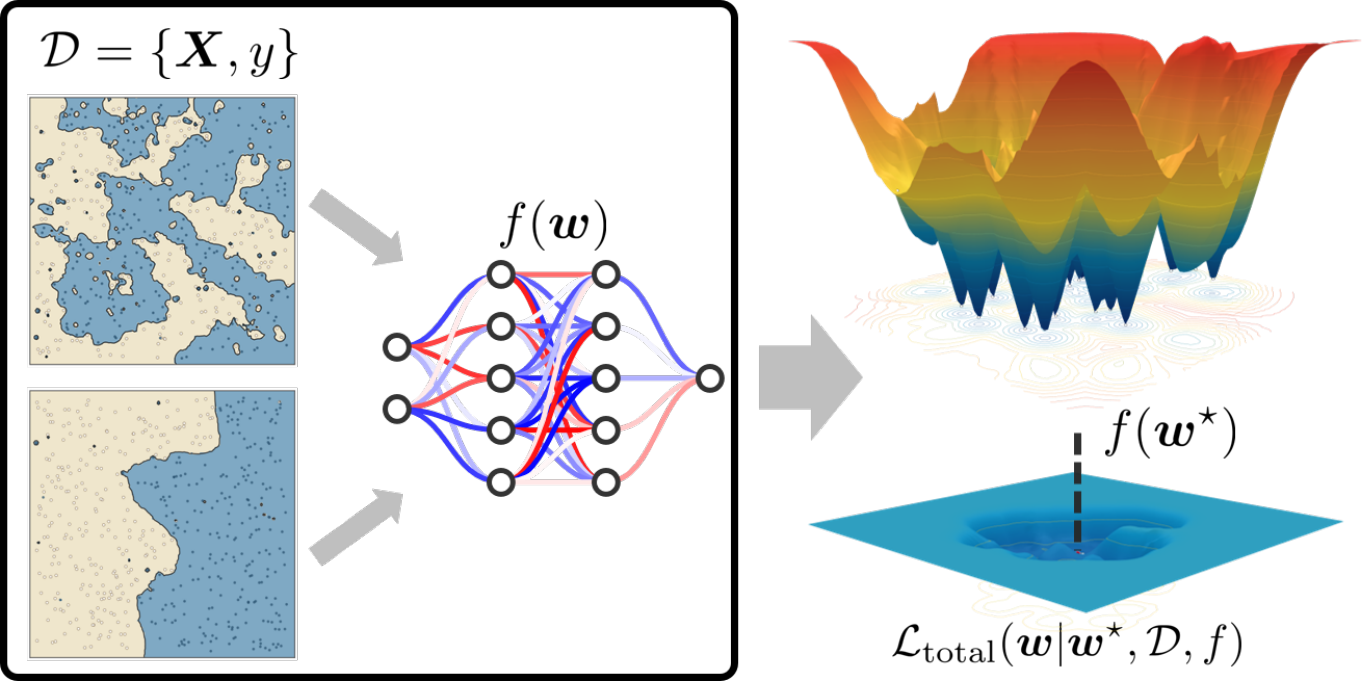

In [2]:
conf = {
    # Golden-ratio reference only: landscape height/width = 1/phi ≈ 0.618; portrait height/width = phi ≈ 1.618.
    "display": {"width_px": 1000},
    # Transparent source padding is removed before matching the source aspect.
    "figure_size": {"width": "one_column", "width_scale": 1.0, "height_ratio": 0.50},
    "asset": {"preserve_source_aspect": True, "crop_transparent_padding": True},
}

fig01(conf)


## Fig. 2: `fig02_perceptron_full_shell`

**Current manuscript location:** Fig. 2; Results--perceptron  
**Output:** `01_theory/fig02_perceptron_full_shell/fig02_perceptron_full_shell`

Inputs:

- `figure_inputs/theory/phi_by_analytic_solution_alpha0p1.csv`
- `figure_inputs/theory/phi_by_sampling.csv`

Edit only `conf`, then run the cell. The imported function contains the plot implementation and writes PDF/PNG/SVG before displaying the PNG inline.

wrote 01_theory/fig02_perceptron_full_shell/fig02_perceptron_full_shell.png


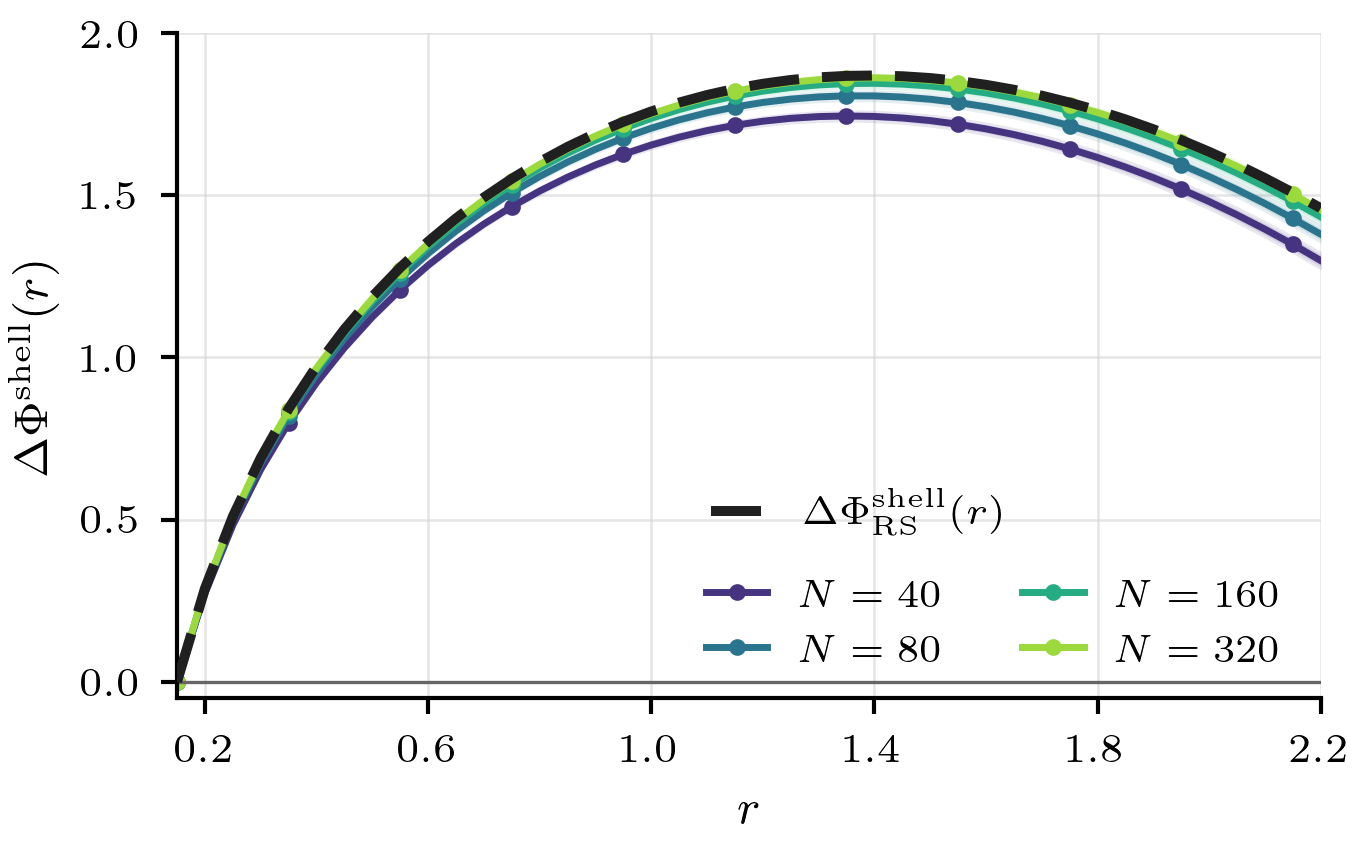

In [3]:
conf = {
    # Golden-ratio reference only: landscape height/width = 1/phi ≈ 0.618; portrait height/width = phi ≈ 1.618.
    "display": {"width_px": 800},
    "figure_size": {"width": "one_column", "width_scale": 1.0, "height_ratio": 0.618},
    "layout": {"constrained": False, "margins": {"left": 0.130, "right": 0.970, "bottom": 0.170, "top": 0.960}},
    "panels": {
        "A": {
            "title": {"text": "", "loc": "left", "pad": 3.0},
            "axes": {
                "x": {"label": r"$r$", "scale": "linear", "limits": (0.15, 2.20), "ticks": (0.2, 0.6, 1.0, 1.4, 1.8, 2.2), "minor_ticks": False},
                "y": {"label": r"$\Delta\Phi^{\mathrm{shell}}(r)$", "scale": "linear", "limits": (-0.05, 1.95), "ticks": (0.0, 0.5, 1.0, 1.5, 2.0), "minor_ticks": False},
            },
            "elements": {"width_scale": 1.0, "height_scale": 1.0},
        },
    },
    "curves": {"analytic_linewidth": 1.8, "smc_linewidth": 1.25, "smc_marker_size": 2.0, "smc_marker_every": 4, "sem_alpha": 0.12},
    "legend": {
        "labels": {
            "analytic": r"$\Delta\Phi^{\mathrm{shell}}_{\mathrm{RS}}(r)$",
            "system_sizes": {
                40: r"$N=40$", 80: r"$N=80$",
                160: r"$N=160$", 320: r"$N=320$",
            },
        },
        # The analytic line and the four SMC sizes are independent legends.
        "analytic": {
            "loc": "lower right", "bbox_to_anchor": (0.74, 0.22),
            "ncol": 1, "handlelength": 1.55, "borderaxespad": 0.0,
        },
        # ncol=2 gives a 2x2 SMC block; use ncol=1 for 1x4.
        "smc": {
            "loc": "lower right", "bbox_to_anchor": (0.98, 0.02),
            "ncol": 2, "handlelength": 1.55, "borderaxespad": 0.0,
        },
    },
}

fig02(conf)


## Fig. 3: `fig03_synthetic_data_complexity`

**Current manuscript location:** Fig. 3; Results--synthetic  
**Output:** `02_dnn_synthetic/fig03_data_complexity/fig03_synthetic_data_complexity`

Inputs:

- `figure_inputs/synthetic/dataset_000/data_beta_0p05.npz`
- `figure_inputs/synthetic/dataset_000/data_beta_0p15.npz`
- `figure_inputs/synthetic/dataset_000/data_beta_0p27.npz`
- `figure_inputs/synthetic/dataset_000/data_beta_0p39.npz`
- `figure_inputs/synthetic/cms_by_dataset.csv`

Edit only `conf`, then run the cell. The imported function contains the plot implementation and writes PDF/PNG/SVG before displaying the PNG inline.

wrote 02_dnn_synthetic/fig03_data_complexity/fig03_synthetic_data_complexity.png


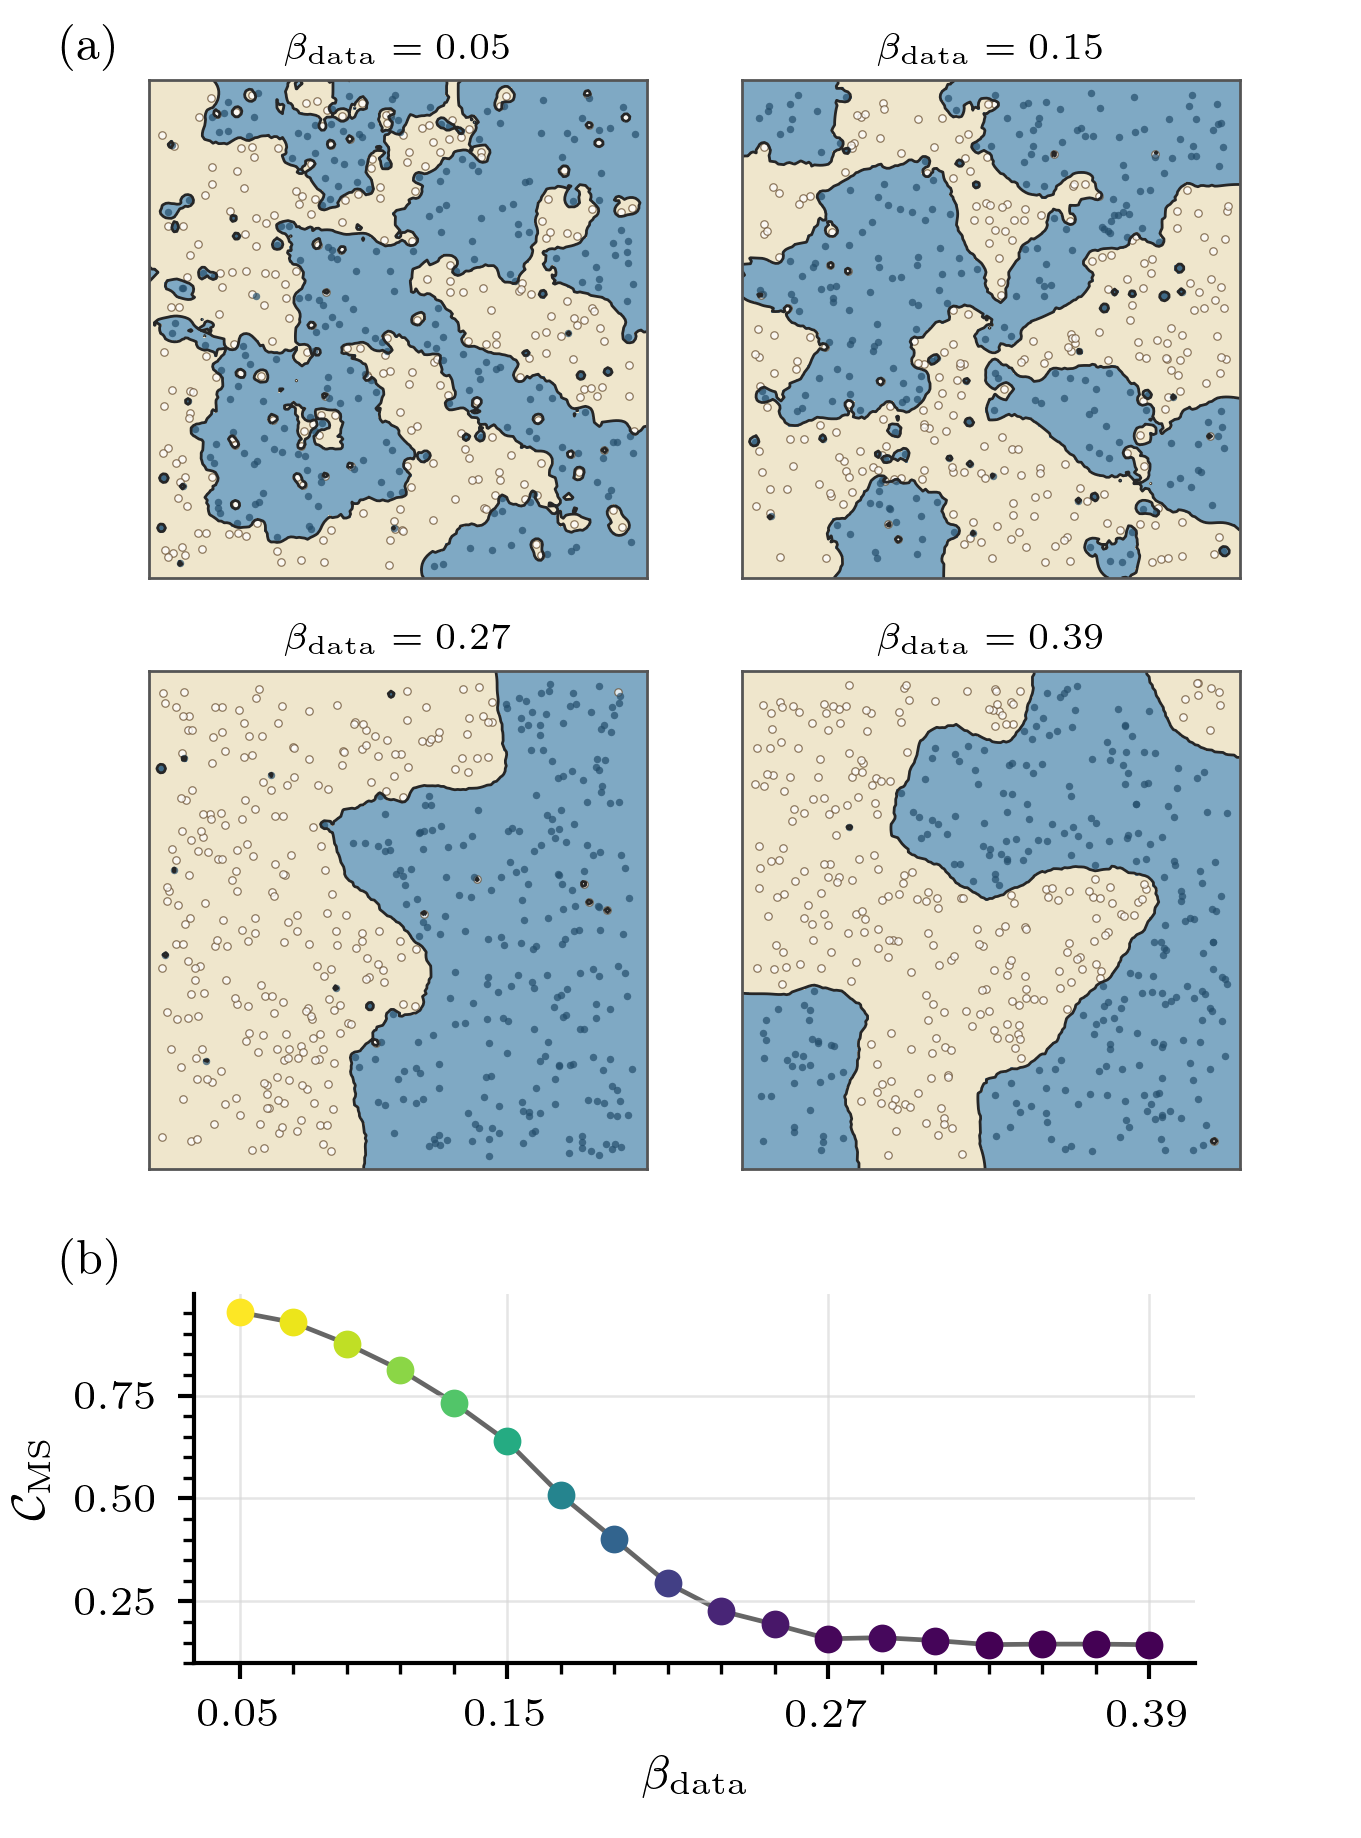

In [4]:
conf = {
    # Golden-ratio reference only: landscape height/width = 1/phi ≈ 0.618; portrait height/width = phi ≈ 1.618.
    "display": {"width_px": 500},
    "figure_size": {"width": "one_column", "width_scale": 1.0, "height_ratio": 1.35},
    "layout": {"margins": {"left": 0.02, "right": 1., "bottom": 0.095, "top": 0.99}},
    "panel_spacing": {"vertical": 0.08},
    "panel_label_layout": {"orientation": "vertical_stack", "offset_left": -0.065, "offset_top": 0.005},
    "panels": {
        "A": {
            "height_weight": 1.15,
            "label": {"text": "(a)"},
            "inner_grid": {"rows": 2, "columns": 2, "wspace": -0.2, "hspace": -0.05},
            "elements": {"width_scale": 0.80, "height_scale": 0.80},
            "element_title_template": r"$\beta_{\mathrm{data}}={beta}$",
            "element_title_style": {"pad": 4.0},
        },
        "B": {
            "height_weight": 0.35,
            "label": {"text": "(b)"},
            "axes": {
                "x": {"label": r"$\beta_{\mathrm{data}}$", "limits": None, "ticks": (0.05, 0.15, 0.27, 0.39), "minor_ticks": False},
                "y": {"label": r"$\mathcal{C}_{\mathrm{MS}}$", "limits": None, "ticks": None, "minor_ticks": True},
            },
            "elements": {"width_scale": 0.75, "height_scale": 1.0},
        },
    },
}

fig03(conf)


## Fig. 4: `fig04_synthetic_landscape`

**Current manuscript location:** Fig. 4; Results--synthetic  
**Output:** `02_dnn_synthetic/fig04_landscape/fig04_synthetic_landscape`

Inputs:

- `figure_inputs/synthetic/energetic_profiles.csv`
- `figure_inputs/synthetic/condition_metrics.csv`
- `figure_inputs/synthetic/cms_by_dataset.csv`

Edit only `conf`, then run the cell. The imported function contains the plot implementation and writes PDF/PNG/SVG before displaying the PNG inline.

wrote 02_dnn_synthetic/fig04_landscape/fig04_synthetic_landscape.png


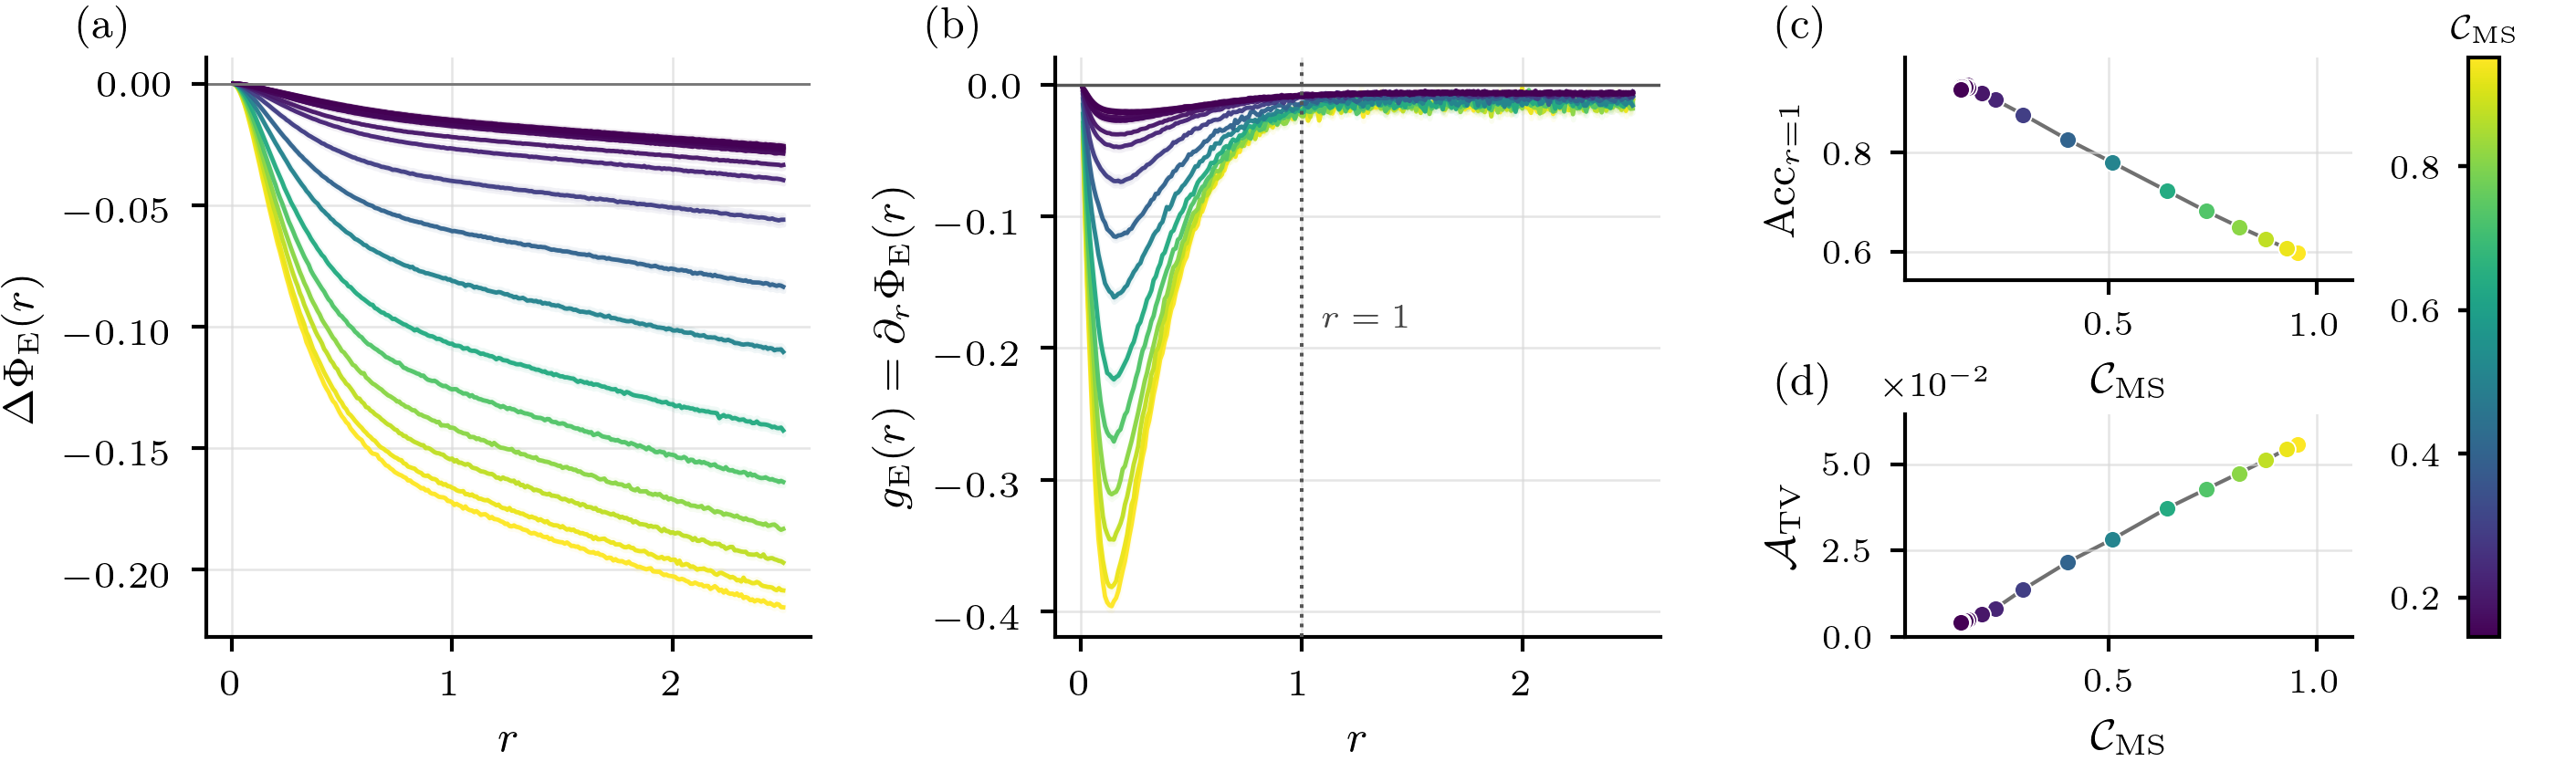

In [5]:
conf = {
    # Golden-ratio reference only: landscape height/width = 1/phi ≈ 0.618; portrait height/width = phi ≈ 1.618.
    "display": {"width_px": 800},
    "figure_size": {"width": "two_column", "width_scale": 1.0, "height_ratio": 0.30},
    "layout": {
        "margins": {"left": 0.080, "right": 1.02, "bottom": 0.175, "top": 0.925},
    },
    "panel_spacing": {"horizontal": 0.58, "vertical": 0.60},
    # Shared by Fig. 4/6/8 panel (d): scientific multiplier such as x10^-2.
    "offset_text": {"x": 0.2, "y": 1.0, "ha": "right", "va": "bottom", "fontsize": 6.7, "visible": True},
    "panel_label_layout": {
        "orientation": "grid", "offset_left": -0.050, "offset_top": 0.012,
        "row_groups": (("A", "B", "C"), ("D",)),
        "column_groups": (("A",), ("B",), ("C", "D")),
    },
    "panels": {
        "A": {
            "width_weight": 1.08,
            "label": {"text": "(a)"},
            "label_style": {"loc": "left", "pad": 3.0},
            "axes": {
                "x": {"label": r"$r$", "limits": None, "ticks": None, "minor_ticks": False},
                "y": {"label": r"$\Delta\Phi_{\mathrm{E}}(r)$", "limits": None, "ticks": None, "minor_ticks": False},
            },
            "elements": {"width_scale": 1.0, "height_scale": 1.0},
        },
        "B": {
            "width_weight": 1.08,
            "label": {"text": "(b)"},
            "label_style": {"loc": "left", "pad": 3.0},
            "axes": {
                "x": {"label": r"$r$", "limits": None, "ticks": None, "minor_ticks": False},
                "y": {"label": r"$g_{\mathrm{E}}(r)=\partial_r\Phi_{\mathrm{E}}(r)$", "limits": None, "ticks": None, "minor_ticks": False},
            },
            "elements": {"width_scale": 1.0, "height_scale": 1.0},
            "annotations": {"r1_label": {"x": 1.5, "y": 0.575, "text": r"$r=1$"}},
        },
        "C": {
            "width_weight": 0.80, "height_weight": 0.7,
            "label": {"text": "(c)"},
            "label_style": {"loc": "left", "pad": 3.0},
            "axes": {
                "x": {"label": r"$\mathcal{C}_{\mathrm{MS}}$", "limits": None, "ticks": None, "minor_ticks": False},
                "y": {"label": r"$\mathrm{Acc}_{r=1}$", "limits": None, "ticks": None, "minor_ticks": False},
            },
            "elements": {"width_scale": 1.0, "height_scale": 1.0},
        },
        "D": {
            "width_weight": 0.80, "height_weight": 0.7,
            "label": {"text": "(d)"},
            "label_style": {"loc": "left", "pad": 3.0},
            "axes": {
                "x": {"label": r"$\mathcal{C}_{\mathrm{MS}}$", "limits": None, "ticks": None, "minor_ticks": False},
                "y": {
                    "label": r"$\mathcal{A}_{\mathrm{TV}}$", "limits": None, "ticks": None, "minor_ticks": False,
                },
            },
            "elements": {"width_scale": 1.0, "height_scale": 1.0},
        },
    },
    "colorbar": {
        "width_weight": 0.055, "orientation": "vertical", "tick_position": "left",
        "title": r"$\mathcal{C}_{\mathrm{MS}}$", "title_kwargs": {"pad": 4.0},
        "tick_params": {"length": 2.0},
        "elements": {"width_scale": 1.0, "height_scale": 1.0, "shift_x": -0.05, "shift_y": 0.0},
    },
}

fig04(conf)


## Fig. 5: `fig05_label_noise_data_complexity`

**Current manuscript location:** Fig. 5; Results--MNIST label noise  
**Output:** `03_dnn_mnist/label_noise_sweep/fig05_data_complexity/fig05_label_noise_data_complexity`

Inputs:

- `figure_inputs/static_assets/label_noise_eta_0p0_composed.pdf`
- `figure_inputs/static_assets/label_noise_eta_0p5_composed.pdf`
- `figure_inputs/mnist_label_noise/cms_by_dataset.csv`

Edit only `conf`, then run the cell. The imported function contains the plot implementation and writes PDF/PNG/SVG before displaying the PNG inline.

wrote 03_dnn_mnist/label_noise_sweep/fig05_data_complexity/fig05_label_noise_data_complexity.png


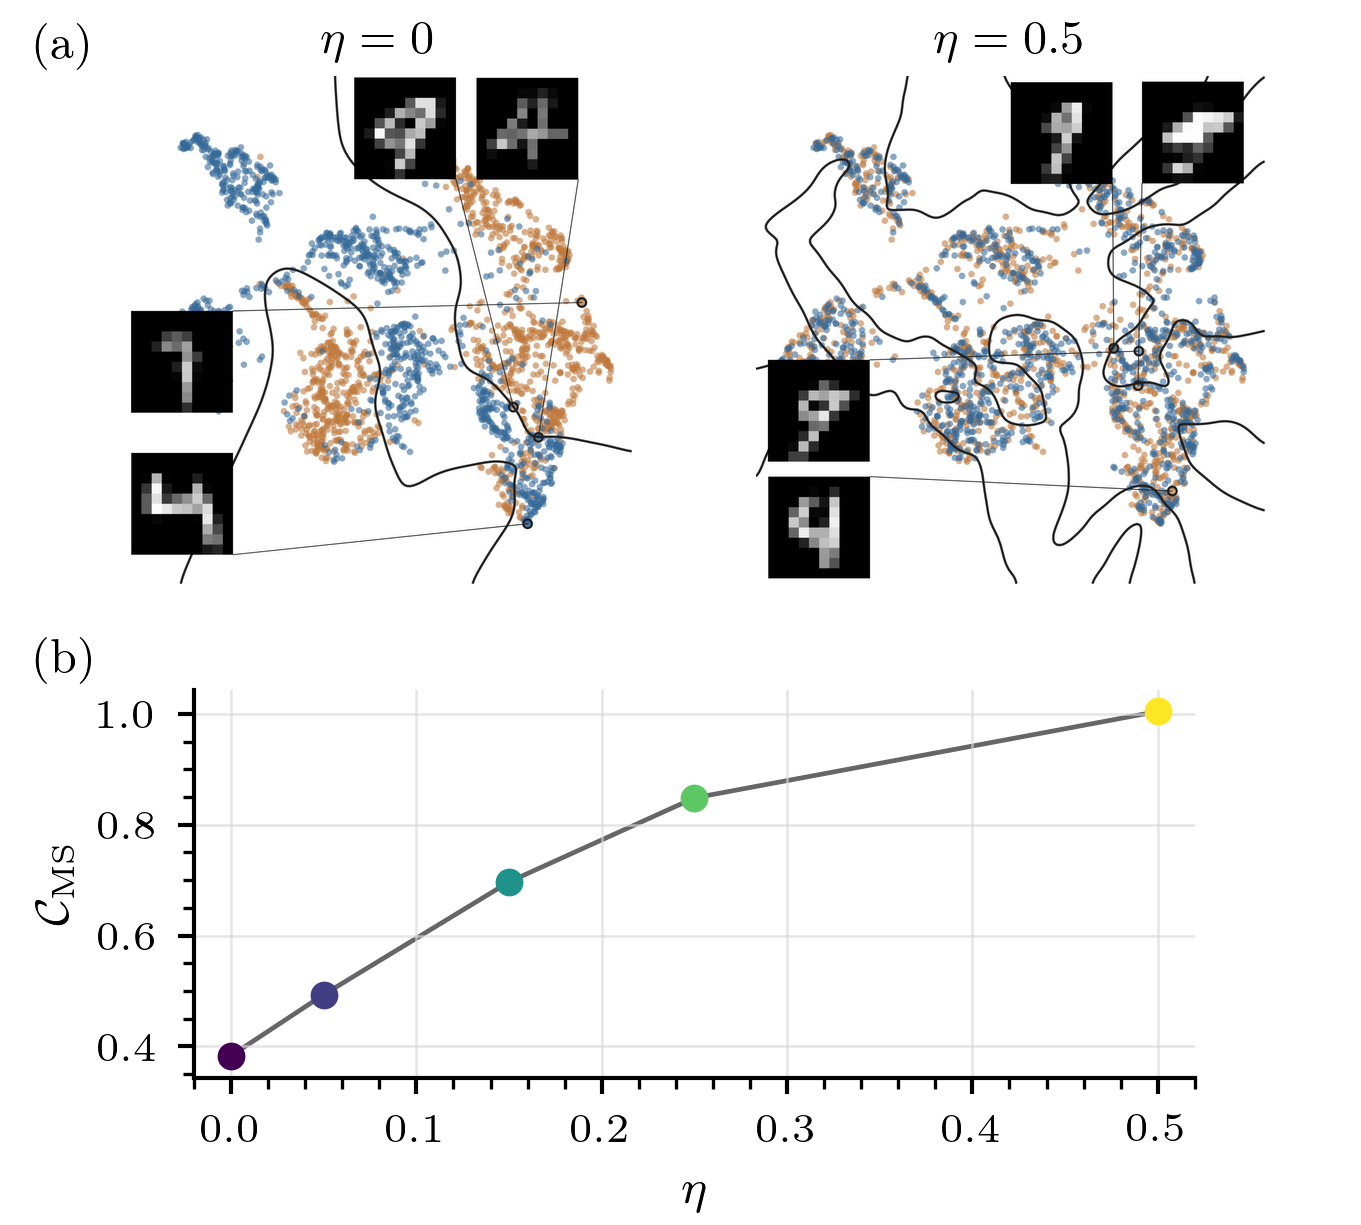

In [6]:
conf = {
    # Golden-ratio reference only: landscape height/width = 1/phi ≈ 0.618; portrait height/width = phi ≈ 1.618.
    "display": {"width_px": 500},
    "figure_size": {"width": "one_column", "width_scale": 1.0, "height_ratio": 1.35/3*2},
    "layout": {"margins": {"left": 0.02, "right": 1, "bottom": 0.12, "top": 0.99}},
    "panel_spacing": {"vertical": 0.08},
    "panel_label_layout": {"orientation": "vertical_stack", "offset_left": -0.065, "offset_top": 0.005},
    "panels": {
        "A": {
            "height_weight": 1.15/2,
            "label": {"text": "(a)"},
            "inner_grid": {"rows": 1, "columns": 2, "wspace": -0.10, "hspace": 0.0},
            "elements": {"width_scale": 0.8, "height_scale": 0.8},
            "element_titles": (r"$\eta=0$", r"$\eta=0.5$"),
            "element_title_style": {"pad": 4.0},
        },
        "B": {
            "height_weight": 0.35,
            "label": {"text": "(b)"},
            "axes": {
                "x": {"label": r"$\eta$", "limits": (-0.02, 0.52), "ticks": (0.0, 0.1, 0.2, 0.3, 0.4, 0.5), "minor_ticks": True},
                "y": {"label": r"$\mathcal{C}_{\mathrm{MS}}$", "limits": None, "ticks": None, "minor_ticks": True},
            },
            "elements": {"width_scale": 0.75, "height_scale": 1.0},
        },
    },
}

fig05(conf)


## Fig. 6: `fig06_label_noise_landscape`

**Current manuscript location:** Fig. 6; Results--MNIST label noise  
**Output:** `03_dnn_mnist/label_noise_sweep/fig06_landscape/fig06_label_noise_landscape`

Inputs:

- `figure_inputs/mnist_label_noise/energetic_profiles.csv`
- `figure_inputs/mnist_label_noise/condition_metrics.csv`
- `figure_inputs/mnist_label_noise/cms_by_dataset.csv`

Edit only `conf`, then run the cell. The imported function contains the plot implementation and writes PDF/PNG/SVG before displaying the PNG inline.

wrote 03_dnn_mnist/label_noise_sweep/fig06_landscape/fig06_label_noise_landscape.png


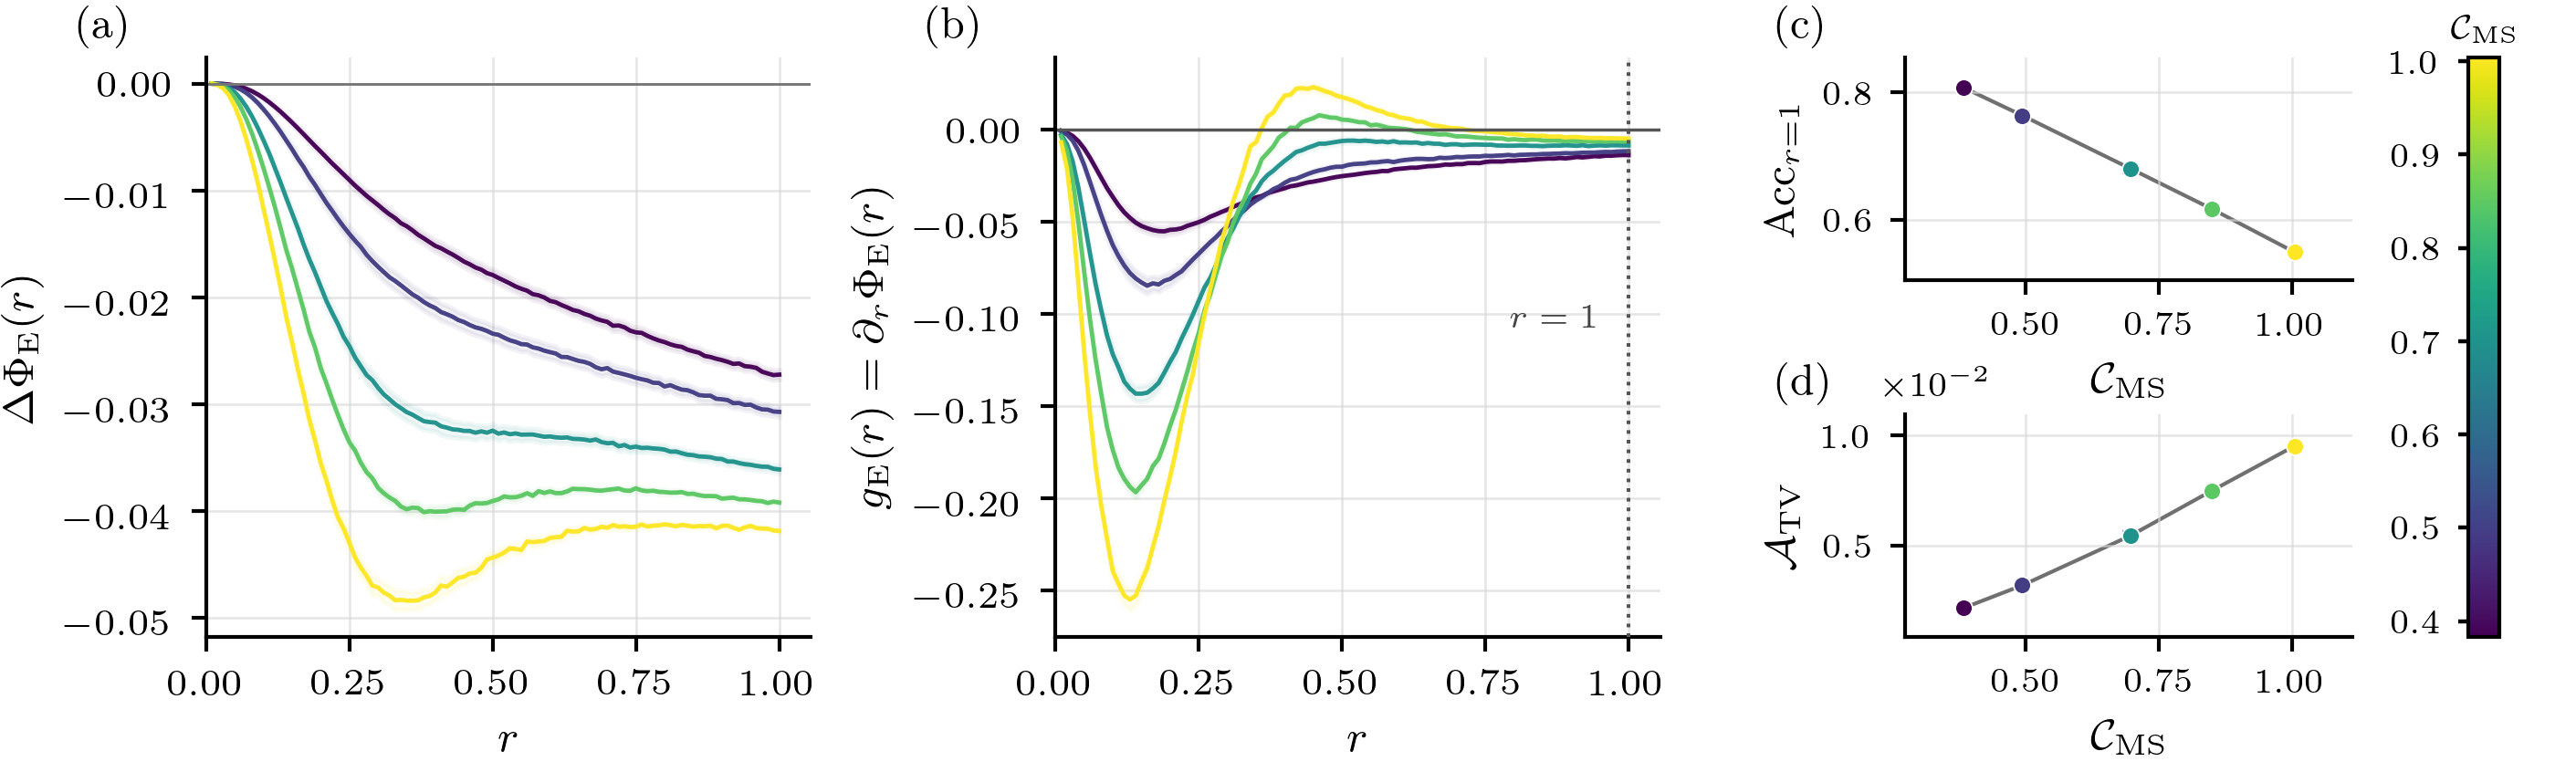

In [7]:
conf = {
    # Golden-ratio reference only: landscape height/width = 1/phi ≈ 0.618; portrait height/width = phi ≈ 1.618.
    "display": {"width_px": 800},
    "figure_size": {"width": "two_column", "width_scale": 1.0, "height_ratio": 0.30},
    "layout": {
        "margins": {"left": 0.080, "right": 1.02, "bottom": 0.175, "top": 0.925},
    },
    "panel_spacing": {"horizontal": 0.58, "vertical": 0.60},
    # Shared by Fig. 4/6/8 panel (d): scientific multiplier such as x10^-2.
    "offset_text": {"x": 0.2, "y": 1.0, "ha": "right", "va": "bottom", "fontsize": 6.7, "visible": True},
    "panel_label_layout": {
        "orientation": "grid", "offset_left": -0.050, "offset_top": 0.012,
        "row_groups": (("A", "B", "C"), ("D",)),
        "column_groups": (("A",), ("B",), ("C", "D")),
    },
    "panels": {
        "A": {
            "width_weight": 1.08,
            "label": {"text": "(a)"},
            "label_style": {"loc": "left", "pad": 3.0},
            "axes": {
                "x": {"label": r"$r$", "limits": None, "ticks": None, "minor_ticks": False},
                "y": {"label": r"$\Delta\Phi_{\mathrm{E}}(r)$", "limits": None, "ticks": None, "minor_ticks": False},
            },
            "elements": {"width_scale": 1.0, "height_scale": 1.0},
        },
        "B": {
            "width_weight": 1.08,
            "label": {"text": "(b)"},
            "label_style": {"loc": "left", "pad": 3.0},
            "axes": {
                "x": {"label": r"$r$", "limits": None, "ticks": None, "minor_ticks": False},
                "y": {"label": r"$g_{\mathrm{E}}(r)=\partial_r\Phi_{\mathrm{E}}(r)$", "limits": None, "ticks": None, "minor_ticks": False},
            },
            "elements": {"width_scale": 1.0, "height_scale": 1.0},
            "annotations": {"r1_label": {"x": 0.95, "y": 0.575, "text": r"$r=1$"}},
        },
        "C": {
            "width_weight": 0.80, "height_weight": 0.7,
            "label": {"text": "(c)"},
            "label_style": {"loc": "left", "pad": 3.0},
            "axes": {
                "x": {"label": r"$\mathcal{C}_{\mathrm{MS}}$", "limits": None, "ticks": None, "minor_ticks": False},
                "y": {"label": r"$\mathrm{Acc}_{r=1}$", "limits": None, "ticks": None, "minor_ticks": False},
            },
            "elements": {"width_scale": 1.0, "height_scale": 1.0},
        },
        "D": {
            "width_weight": 0.80, "height_weight": 0.7,
            "label": {"text": "(d)"},
            "label_style": {"loc": "left", "pad": 3.0},
            "axes": {
                "x": {"label": r"$\mathcal{C}_{\mathrm{MS}}$", "limits": None, "ticks": None, "minor_ticks": False},
                "y": {
                    "label": r"$\mathcal{A}_{\mathrm{TV}}$", "limits": None, "ticks": None, "minor_ticks": False,
                },
            },
            "elements": {"width_scale": 1.0, "height_scale": 1.0},
        },
    },
    "colorbar": {
        "width_weight": 0.055, "orientation": "vertical", "tick_position": "left",
        "title": r"$\mathcal{C}_{\mathrm{MS}}$", "title_kwargs": {"pad": 4.0},
        "tick_params": {"length": 2.0},
        "elements": {"width_scale": 1.0, "height_scale": 1.0, "shift_x": -0.05, "shift_y": 0.0},
    },
}

fig06(conf)


## Fig. 7: `fig07_digit_pair_data_complexity`

**Current manuscript location:** Fig. 7; Results--MNIST digit pairs  
**Output:** `03_dnn_mnist/digit_pairwise_complexity/fig07_data_complexity/fig07_digit_pair_data_complexity`

Inputs:

- `figure_inputs/static_assets/digit_pair_lowest_complexity_pair_0_1_composed.pdf`
- `figure_inputs/static_assets/digit_pair_highest_complexity_pair_4_9_composed.pdf`
- `figure_inputs/mnist_digit_pair/cms_by_dataset.csv`
- `figure_inputs/mnist_digit_pair/frozen_pair_manifest.json`

Edit only `conf`, then run the cell. The imported function contains the plot implementation and writes PDF/PNG/SVG before displaying the PNG inline.

wrote 03_dnn_mnist/digit_pairwise_complexity/fig07_data_complexity/fig07_digit_pair_data_complexity.png


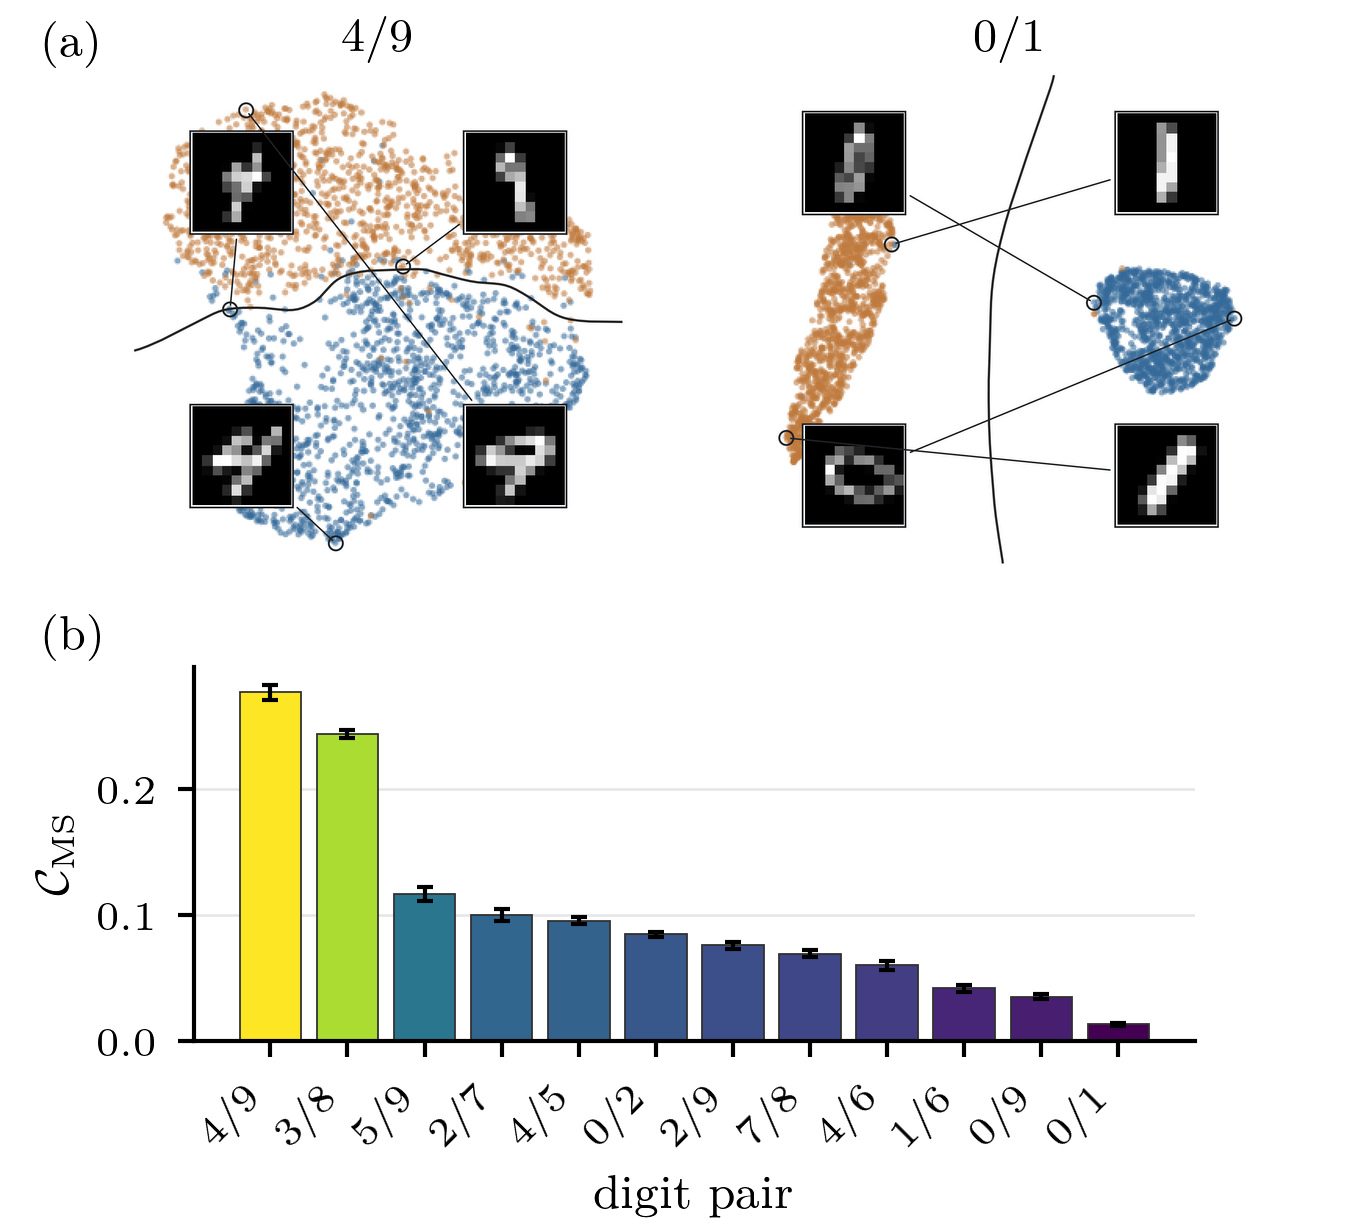

In [8]:
conf = {
    # Golden-ratio reference only: landscape height/width = 1/phi ≈ 0.618; portrait height/width = phi ≈ 1.618.
    "display": {"width_px": 500},
    "figure_size": {"width": "one_column", "width_scale": 1.0, "height_ratio": 1.35/3*2},
    "layout": {"margins": {"left": 0.02, "right": 1, "bottom": 0.15, "top": 0.99}},
    "panel_spacing": {"vertical": 0.08},
    "panel_label_layout": {"orientation": "vertical_stack", "offset_left": -0.065, "offset_top": 0.005},
    "panels": {
        "A": {
            "height_weight": 1.15/2,
            "label": {"text": "(a)"},
            "inner_grid": {"rows": 1, "columns": 2, "wspace": -0.10, "hspace": 0.0},
            "elements": {"width_scale": 0.8, "height_scale": 0.8},
            "element_titles": ("4/9", "0/1"),
            "element_title_style": {"pad": 4.0},
        },
        "B": {
            "height_weight": 0.35,
            "label": {"text": "(b)"},
            "axes": {
                "x": {"label": "digit pair", "limits": None, "ticks": None, "tick_rotation": 45, "tick_ha": "right", "minor_ticks": False},
                "y": {"label": r"$\mathcal{C}_{\mathrm{MS}}$", "limits": None, "ticks": None, "minor_ticks": False},
            },
            "elements": {"width_scale": 0.75, "height_scale": 1.0},
        },
    },
}

fig07(conf)


## Fig. 8: `fig08_digit_pair_landscape`

**Current manuscript location:** Fig. 8; Results--MNIST digit pairs  
**Output:** `03_dnn_mnist/digit_pairwise_complexity/fig08_landscape/fig08_digit_pair_landscape`

Inputs:

- `figure_inputs/mnist_digit_pair/energetic_profiles.csv`
- `figure_inputs/mnist_digit_pair/condition_metrics.csv`
- `figure_inputs/mnist_digit_pair/cms_by_dataset.csv`

Edit only `conf`, then run the cell. The imported function contains the plot implementation and writes PDF/PNG/SVG before displaying the PNG inline.

wrote 03_dnn_mnist/digit_pairwise_complexity/fig08_landscape/fig08_digit_pair_landscape.png


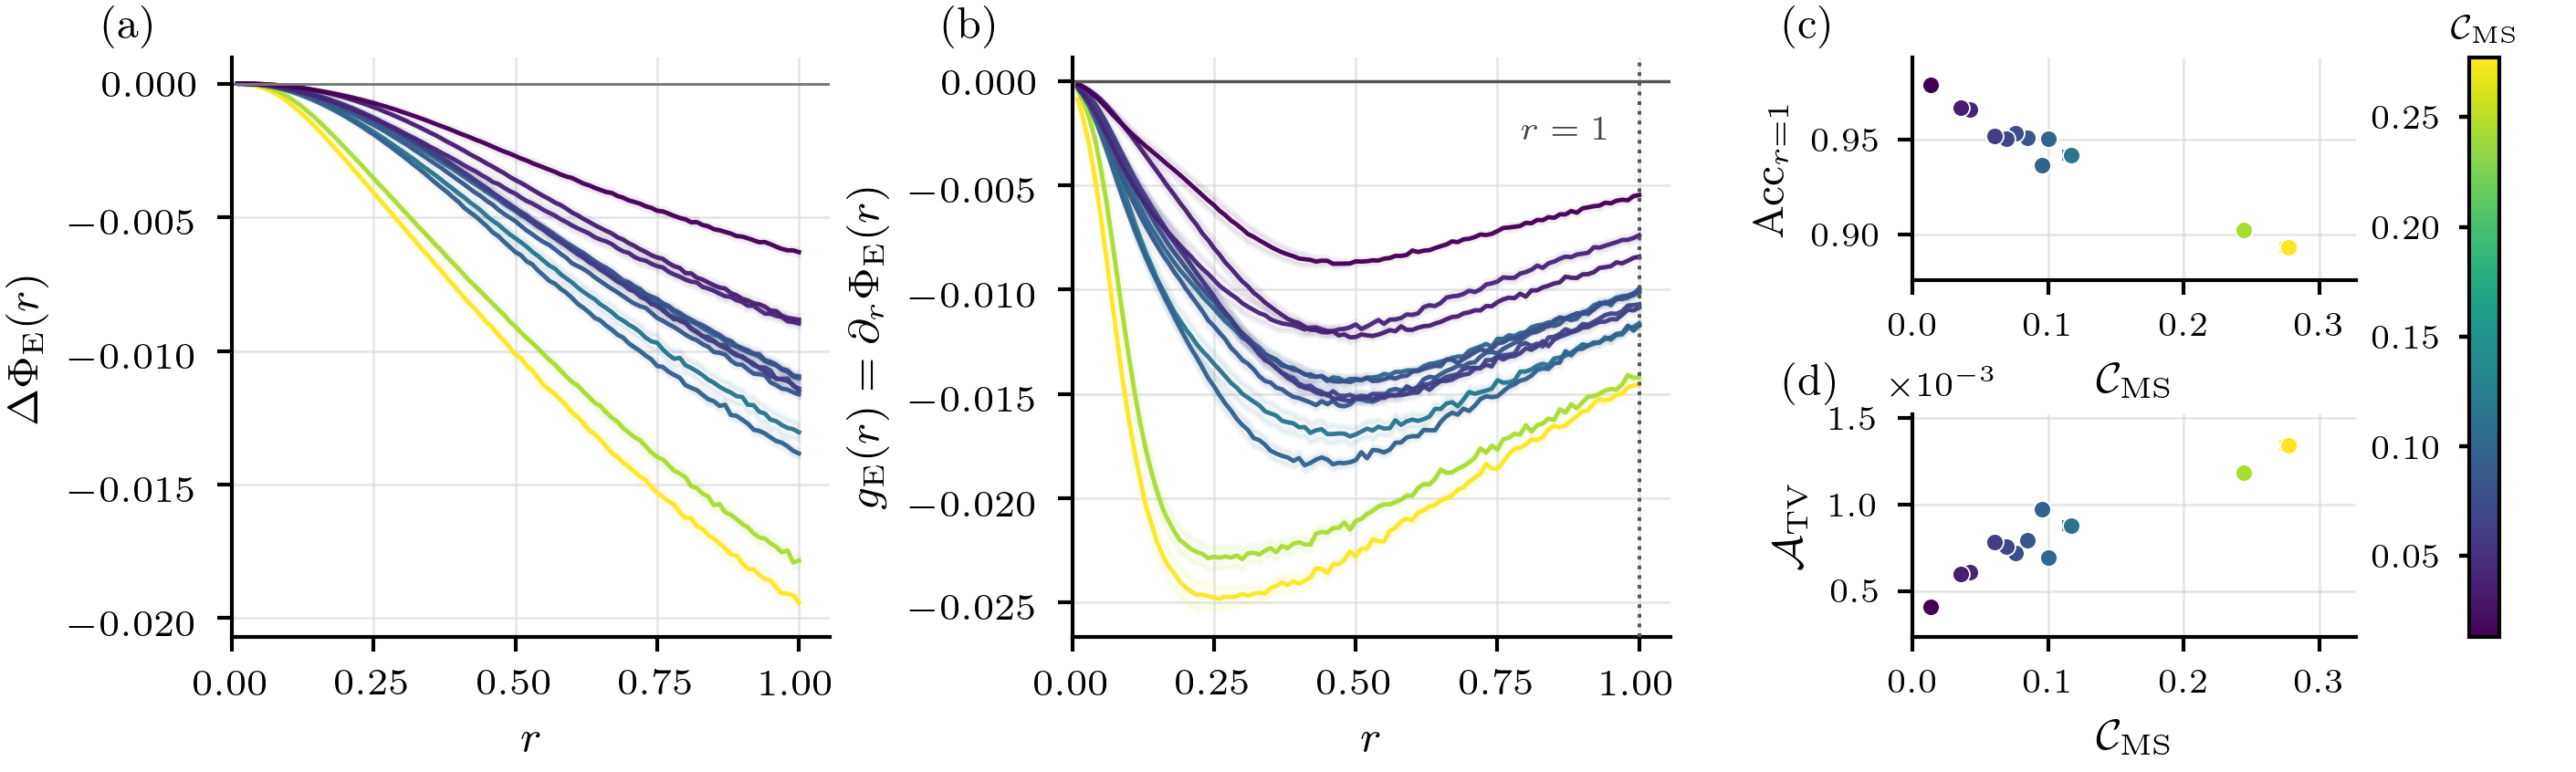

In [9]:
conf = {
    # Golden-ratio reference only: landscape height/width = 1/phi ≈ 0.618; portrait height/width = phi ≈ 1.618.
    "display": {"width_px": 800},
    "figure_size": {"width": "two_column", "width_scale": 1.0, "height_ratio": 0.30},
    "layout": {
        "margins": {"left": 0.09, "right": 1.02, "bottom": 0.175, "top": 0.925},
    },
    "panel_spacing": {"horizontal": 0.58, "vertical": 0.60},
    # Shared by Fig. 4/6/8 panel (d): scientific multiplier such as x10^-2.
    "offset_text": {"x": 0.2, "y": 1.0, "ha": "right", "va": "bottom", "fontsize": 6.7, "visible": True},
    "panel_label_layout": {
        "orientation": "grid", "offset_left": -0.050, "offset_top": 0.012,
        "row_groups": (("A", "B", "C"), ("D",)),
        "column_groups": (("A",), ("B",), ("C", "D")),
    },
    "panels": {
        "A": {
            "width_weight": 1.08,
            "label": {"text": "(a)"},
            "label_style": {"loc": "left", "pad": 3.0},
            "axes": {
                "x": {"label": r"$r$", "limits": None, "ticks": None, "minor_ticks": False},
                "y": {"label": r"$\Delta\Phi_{\mathrm{E}}(r)$", "limits": None, "ticks": None, "minor_ticks": False},
            },
            "elements": {"width_scale": 1.0, "height_scale": 1.0},
        },
        "B": {
            "width_weight": 1.08,
            "label": {"text": "(b)"},
            "label_style": {"loc": "left", "pad": 3.0},
            "axes": {
                "x": {"label": r"$r$", "limits": None, "ticks": None, "minor_ticks": False},
                "y": {"label": r"$g_{\mathrm{E}}(r)=\partial_r\Phi_{\mathrm{E}}(r)$", "limits": None, "ticks": None, "minor_ticks": False},
            },
            "elements": {"width_scale": 1.0, "height_scale": 1.0},
            "annotations": {"r1_label": {"x": 0.95, "y": 0.9, "text": r"$r=1$"}},
        },
        "C": {
            "width_weight": 0.80, "height_weight": 0.7,
            "label": {"text": "(c)"},
            "label_style": {"loc": "left", "pad": 3.0},
            "axes": {
                "x": {"label": r"$\mathcal{C}_{\mathrm{MS}}$", "limits": None, "ticks": None, "minor_ticks": False},
                "y": {"label": r"$\mathrm{Acc}_{r=1}$", "limits": None, "ticks": None, "minor_ticks": False},
            },
            "elements": {"width_scale": 1.0, "height_scale": 1.0},
        },
        "D": {
            "width_weight": 0.80, "height_weight": 0.7,
            "label": {"text": "(d)"},
            "label_style": {"loc": "left", "pad": 3.0},
            "axes": {
                "x": {"label": r"$\mathcal{C}_{\mathrm{MS}}$", "limits": None, "ticks": None, "minor_ticks": False},
                "y": {
                    "label": r"$\mathcal{A}_{\mathrm{TV}}$", "limits": None, "ticks": None, "minor_ticks": False,
                },
            },
            "elements": {"width_scale": 1.0, "height_scale": 1.0},
        },
    },
    "colorbar": {
        "width_weight": 0.055, "orientation": "vertical", "tick_position": "left",
        "title": r"$\mathcal{C}_{\mathrm{MS}}$", "title_kwargs": {"pad": 4.0},
        "tick_params": {"length": 2.0},
        "elements": {"width_scale": 1.0, "height_scale": 1.0, "shift_x": -0.05, "shift_y": 0.0},
    },
}

fig08(conf)


## Fig. 9: `fig09_hardening_3d_composite`

**Current manuscript location:** Fig. 9; Discussion  
**Output:** `04_discussion/fig09_hardening_3d_composite/fig09_hardening_3d_composite`

Inputs:

- `figure_inputs/discussion/normalized_radial_profiles.csv`

Edit only `conf`, then run the cell. The imported function contains the plot implementation and writes PDF/PNG/SVG before displaying the PNG inline.

**Schematic interpretation:** Panels (b,c) are qualitative 3-D analogues of lower- and higher-complexity low-loss landscapes. Their corridor orientation and surface geometry are illustrative, not measured loss slices, empirically identified directions, or independently fitted direction trajectories.

wrote 04_discussion/fig09_hardening_3d_composite/fig09_hardening_3d_composite.png


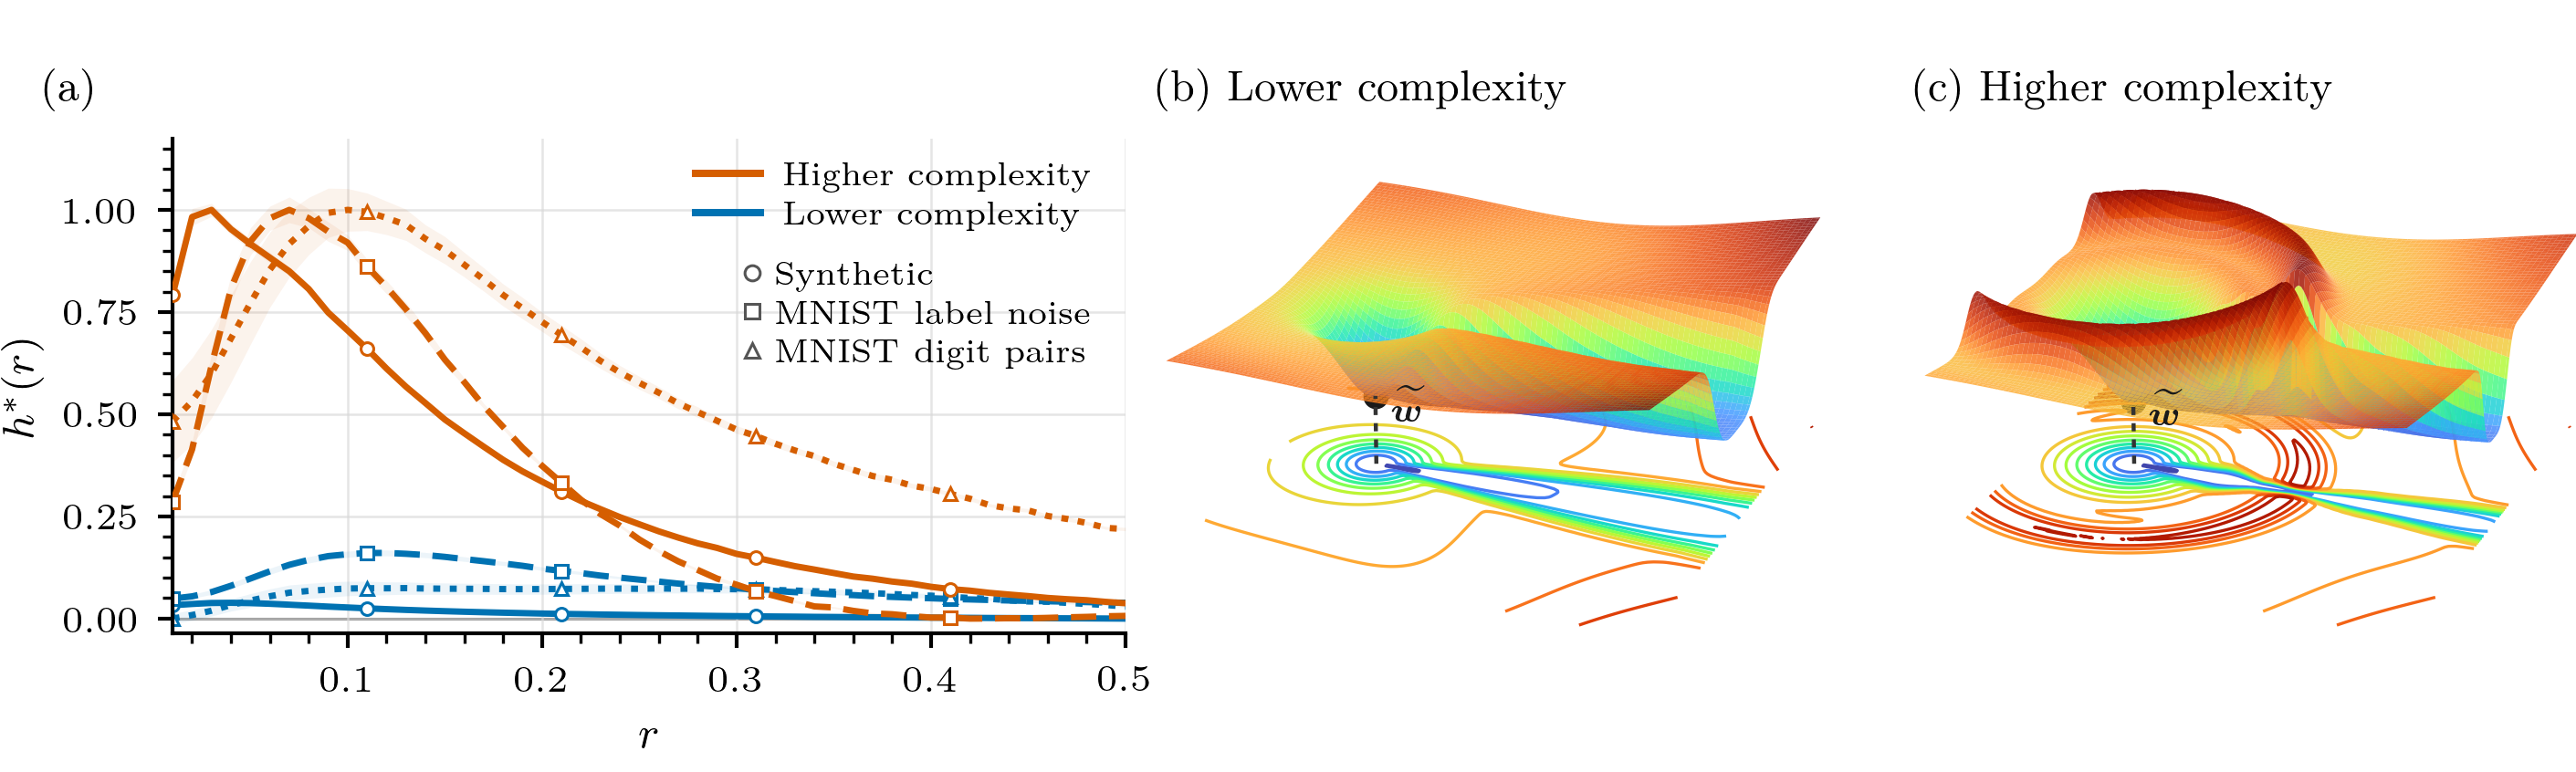

In [10]:
conf = {
    # Golden-ratio reference only: landscape height/width = 1/phi ≈ 0.618; portrait height/width = phi ≈ 1.618.
    "display": {"width_px": 1200},
    "figure_size": {"width": "two_column", "width_scale": 1.0, "height_ratio": 0.3},
    "layout": {"margins": {"left": 0.067, "right": 0.995, "bottom": -0.3, "top": 1.3}},
    "panel_spacing": {"horizontal": -0.01},
    # All three labels share exactly one y coordinate; x follows each panel's left edge.
    "panel_label_layout": {"orientation": "horizontal_row", "offset_left": 0.0, "offset_top": 0.006},
    "panels": {
        "A": {
            "width_weight": 1.52,
            # Per-label adjustment: +x=right, +y=up. Keep all offsets equal for alignment.
            "label": {
                "text": "(a)", "offset_x": -0.05, "offset_y": -0.12,
                "style": {"fontsize": 8.5, "ha": "left", "va": "bottom"},
            },
            "label_style": {"loc": "left", "pad": 6.0},
            "axes": {
                "x": {"label": r"$r$", "limits": (0.01, 0.50), "ticks": (0.10, 0.20, 0.30, 0.40, 0.50), "minor_ticks": True},
                "y": {"label": r"$h^{\ast}(r)$", "limits": (-0.035, 1.175), "ticks": (0.0, 0.25, 0.50, 0.75, 1.0), "minor_ticks": True},
            },
            "elements": {"width_scale": 1, "height_scale": 0.4},
            "curves": {"band_alpha": 0.075, "line_width": 1.25, "marker_size": 2.5, "marker_every": 10},
        },
        "B": {
            "width_weight": 1.16, "regime": "lower",
            "label": {
                "text": "(b)  Lower complexity", "offset_x": 0.01, "offset_y": -0.12,
                "style": {"fontsize": 8.5, "ha": "left", "va": "bottom"},
            },
            "subtitle": "", "title_pad": 0.0,
            "reference_label": r"$\widetilde{\boldsymbol w}$",
            "elements": {"width_scale": 1.0, "height_scale": 1.0, "shift_x": 0.005, "shift_y": 0.0},
            "view": {"elevation": 24.0, "azimuth": -68.0, "roll": 0.0, "projection": "persp"},
        },
        "C": {
            "width_weight": 1.16, "regime": "higher",
            "label": {
                "text": "(c)  Higher complexity", "offset_x": 0.01, "offset_y": -0.12,
                "style": {"fontsize": 8.5, "ha": "left", "va": "bottom"},
            },
            "subtitle": "", "title_pad": 0.0,
            "reference_label": r"$\widetilde{\boldsymbol w}$",
            "elements": {"width_scale": 1.0, "height_scale": 1.0, "shift_x": 0.020, "shift_y": 0.0},
            "view": {"elevation": 24.0, "azimuth": -68.0, "roll": 0.0, "projection": "persp"},
        },
    },
    "legend": {
        "labels": {
            "higher": "Higher complexity", "lower": "Lower complexity",
            "synthetic": "Synthetic", "mnist_label_noise": "MNIST label noise",
            "mnist_digit_pair": "MNIST digit pairs",
        },
        "complexity": {
            "loc": "upper right", "bbox_to_anchor": (0.98, 0.98),
            "ncol": 1, "fontsize": 6.7, "labelspacing": 0.25,
            "handlelength": 1.9, "handletextpad": 0.70,
            "borderaxespad": 0.0, "frameon": False,
        },
        "studies": {
            "loc": "upper right", "bbox_to_anchor": (0.98, 0.78),
            "ncol": 1, "fontsize": 6.7, "labelspacing": 0.25,
            "handlelength": 0.0, "handletextpad": 0.70,
            "borderaxespad": 0.0, "frameon": False,
        },
        "styles": {
            "complexity": {"line_width": 1.45},
            "studies": {"color": "#555555", "marker_size": 3.0, "marker_edge_width": 0.55},
        },
    },
    "surface": {
        "xlim": (-0.34, 1.25), "ylim": (-0.82, 0.82),
        "points": 180, "surface_count": 120,
        "cmap": "turbo", "alpha": 0.83, "contour_levels": 13,
        "projection_drop": 0.42, "bowl_strength": 0.12,
        "wall_height": 0.58, "pinch_height": 0.34,
        "pinch_radius": 0.56, "pinch_width": 0.085,
        "pre_bulge_height": 0.14, "pre_bulge_radius": 0.36, "pre_bulge_width": 0.10,
        "undulation": 0.035, "reference_marker_size": 16.0,
        "reference_label_z_offset": 0.0,
        "reference_line": {
            "enabled": True, "bottom_offset": 0.0, "top_offset": 0.0,
            "color": "#333333", "linewidth": 0.8,
            "linestyle": (0, (2.0, 2.0)), "zorder": 21,
        },
        "reference_label_position": {"offset_x": 0.045, "offset_y": 0.025, "z_fraction": 0.62},
        "box_aspect": (1.45, 1.5, 0.72), "geometry": {},
    },
}

fig09(conf)


## Final audit

Validate all 9 arXiv v1 figures and display the contact sheet.

wrote receipts/visual_audit_contact_sheet.png: 2096x6829
Notebook rebuild PASS: 9 figures; 27 exported files


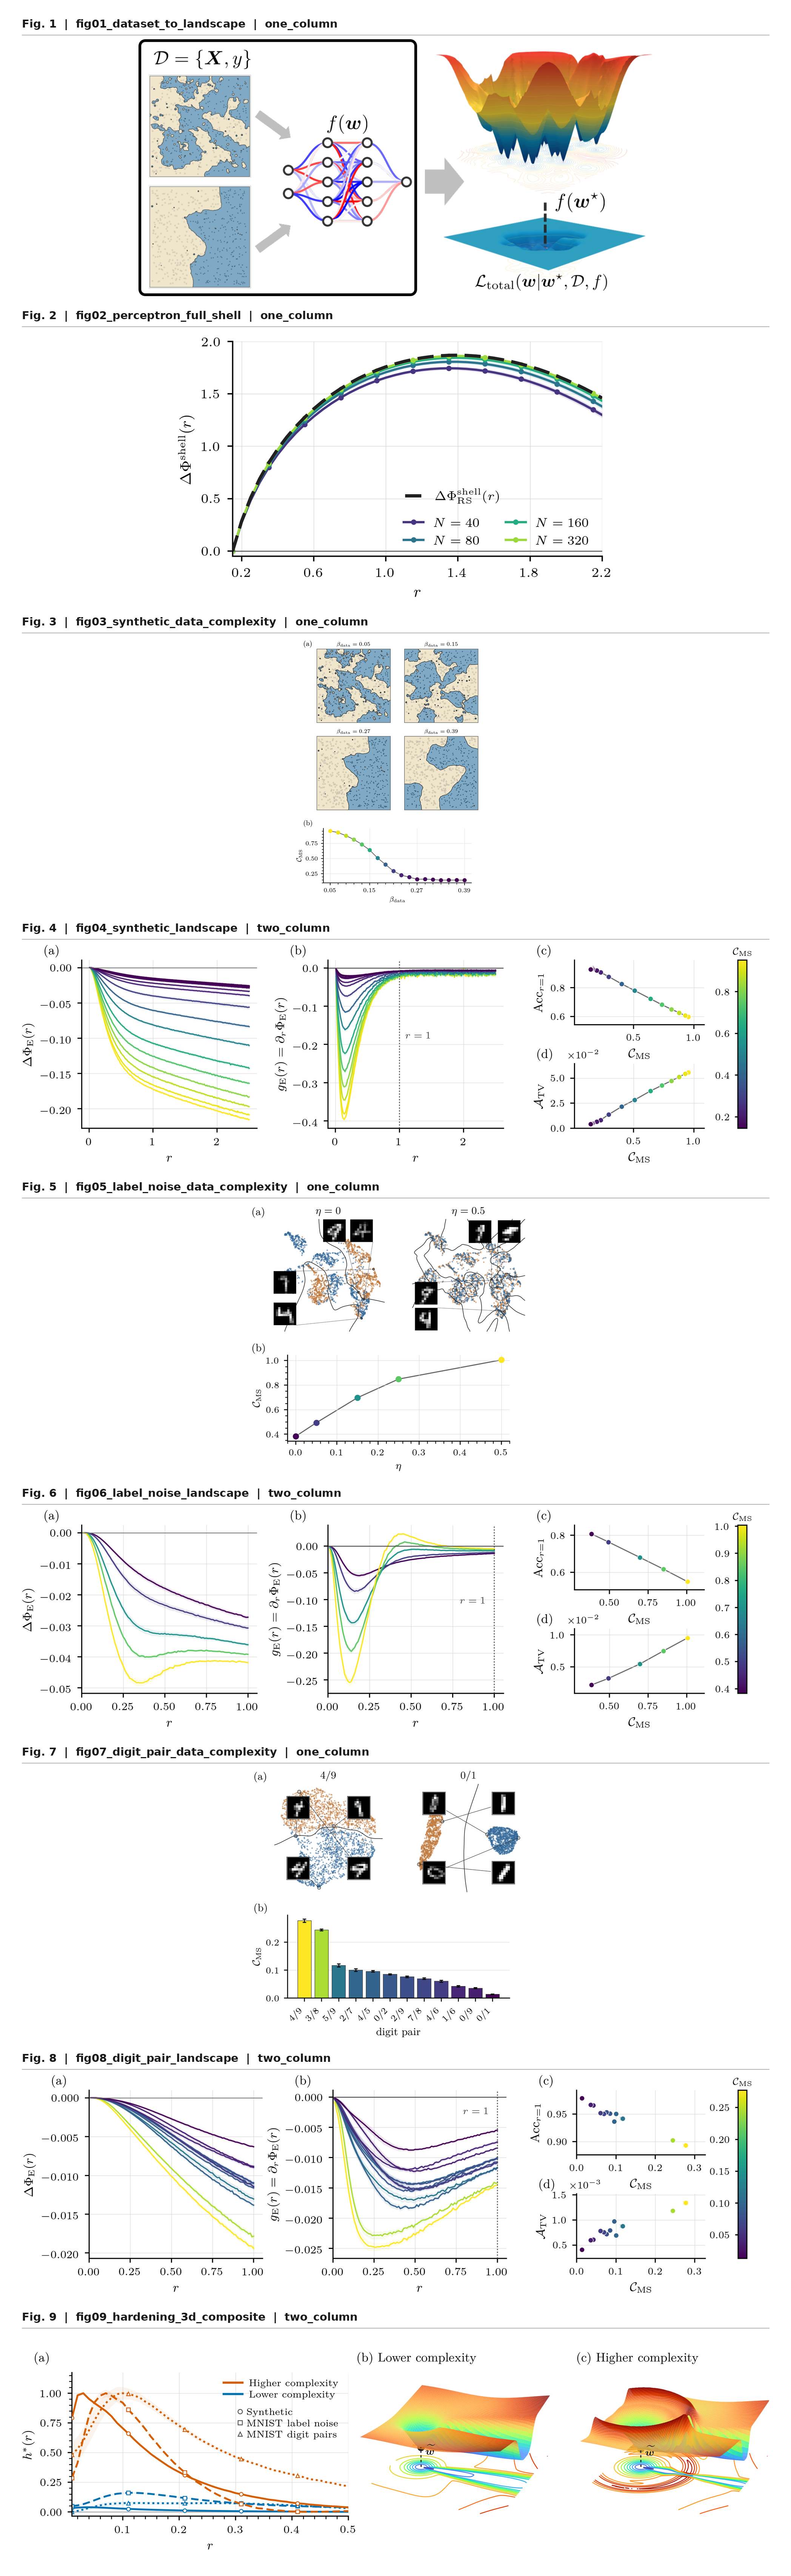

In [11]:
receipt = final_audit()
